# **Decoding the Cold War: Finding Global Blocs**

## Scalable Geopolitical Network Analysis with NetworkX, Scipy Sparse and Dask

<br>

In this tutorial, we will explore the [Correlates of War (COW) Formal Alliance dataset](https://correlatesofwar.org/data-sets/formal-alliances/) to build and analyze the network of nations. Our goal is to uncover hidden structures in international alliances and identify geopolitical communities from the Cold War era. We'll guide you from a raw dataset to a quantitative and visual analysis of global power structures through the following steps:
- Explore and process the time-series alliance data with Dask DataFrames.
- Transform historical records into a network graph representation.
- Implement and compare two foundational community detection algorithms: Girvan-Newman and Spectral Clustering.
- Use `scikit-learn` for sparse matrix representation and `networkx` for graph analysis.
- Interpret the results in a real-world geopolitical context.

**Credits**

This tutorial is created by Peter Zhang using dataset from the [**Correlates of War Project**](https://correlatesofwar.org/data-sets/formal-alliances/).

**Compatibility**

| Platform                     | Compatible |  Recommended  | Notes                                                                                                                                   |
| :--------------------------- | :--------: | :-----------: | :-------------------------------------------------------------------------------------------------------------------------------------- |
| **Local (e.g., MacBook/PC)** |   ✅ Yes   |   ✅ Yes      | The COW dataset is small and can be processed efficiently on local machine, making it an ideal setup for learning and practicing the workflow.                                          |
| **Google Colab**             |   ✅ Yes   |   ✅ Yes      | Works well. May require installing libraries: `!pip install "dask[complete]" networkx`                                                  |
| **Midway3 Login Node**       |   ✅ Yes   |    ✅ Yes     | Install Dask and run this on any login nodes. Dask will handle the Slurm job provisioning under the hood.                               |
| **Midway3 Compute Node**     |   ✅ Yes   |   ✅ Yes      | Ideal for this tutorial and for scaling up to larger datasets. Use `LocalCluster()` instead.                                            |


## **Task Description**

The goal is to analyze the **Correlates of War (COW) Formal Alliance dataset** and identify the major geopolitical blocs of the Cold War era (1947–1991).

We will begin by processing the alliance dataset with Dask to construct a network graph, where each node representes a country and each alliance forms an edge connecting two countries. Then, we will apply and compare two community detection algorithms—the divisive Girvan-Newman method and the matrix-based Spectral Clustering—to partition the network.

We will interpret the discovered communities by comparing them with the historical understanding of the East-West divide and other significant international coalitions of that period.


## **The Data: COW Dyadic Alliances**

We'll use a **dyadic version** of the [COW Formal Alliance dataset](https://correlatesofwar.org/data-sets/formal-alliances/), where each row represents a single relationship (_dyad_) between two countries for a specific period.

We will create a network graph representing all active alliances during the Cold War using the key columns:
- `ccode1`, `ccode2`: the country code for the pair.
- `state_name1`, `state_name2`: the corresponding country names.
- `dyad_st_year`: the year the alliance between the dyad began.
- `dyad_end_year`: the year the alliance ended.


## **Step 1: Data Processing with Dask**

Let's start by setting up our environment and loading the data with `dask.dataframe` (it provides a pandas-like experience for out-of-memory datasets). More detailed information are available in the official [Dask DataFrame documentation](https://docs.dask.org/en/stable/dataframe.html).


In [ ]:
# First, make sure you have the necessary libraries installed
%pip install -y dask dask_jobqueue pandas networkx scikit-learn matplotlib

In [ ]:
import os

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community.centrality import girvan_newman
from networkx.algorithms.community import modularity

import dask.array as da
import dask.dataframe as dd
from scipy.sparse import coo_matrix
from sklearn.cluster import SpectralClustering

from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster

In [ ]:
# Run this block if you are on Colab or a Midway compute node
# cluster = LocalCluster()

/usr/local/lib/python3.12/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39343 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:40051
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:39343/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34729'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:45121'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:39981 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:39981
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:38934
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:43697 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:43697
IN

In [ ]:
# Run this cell if you're on Midway login node
# This is the recommended way to run dask notebooks
# where SLURM job submission will be automatically handled by dask_jobqueue

SLURM_ACCOUNT = "macs40123"

# Create logging dir
os.makedirs("./logs", exist_ok=True)

# Compose SLURM script
cluster = SLURMCluster(
    queue="amd",
    cores=10,
    memory="60GB",
    processes=10,
    walltime="04:00:00",
    interface="ib0",
    job_extra_directives=[
        f"--account={SLURM_ACCOUNT}",
        "--output=logs/dask-%j.out",
        "--error=logs/dask-%j.err",
    ],
)

# Request resources
cluster.scale(jobs=1)

In [ ]:
client = Client(cluster)
client

INFO:distributed.scheduler:Receive client connection: Client-6e0402e8-ae41-11f0-809c-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:38986


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:39343/status,
Dashboard: http://127.0.0.1:39343/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40051,Workers: 0
Dashboard: http://127.0.0.1:39343/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39981,Total threads: 1
Dashboard: http://127.0.0.1:41891/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:34729,


In [ ]:
# Run this to download the dataset if you are running this notebook standalone on Google Colab
!wget https://correlatesofwar.org/wp-content/uploads/version4.1_csv.zip
!unzip version4.1_csv.zip
!mv version4.1_csv alliance_v4.1

In [ ]:
# Load the data using Dask
ddf = dd.read_csv("./alliance_v4.1/alliance_v4.1_by_dyad.csv", assume_missing=True)

# Let's inspect the first few rows and data types without loading the whole file
ddf.head()

,version4id,ccode1,state_name1,ccode2,state_name2,dyad_st_day,dyad_st_month,dyad_st_year,dyad_end_day,dyad_end_month,dyad_end_year,left_censor,right_censor,defense,neutrality,nonaggression,entente,asymmetric,version
0,1.0,200.0,United Kingdom,235.0,Portugal,1.0,1.0,1816.0,NaN,NaN,NaN,1.0,1.0,1.0,0.0,1.0,0.0,0.0,4.1
1,2.0,200.0,United Kingdom,380.0,Sweden,1.0,1.0,1816.0,15.0,2.0,1911.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,4.1
2,3.0,240.0,Hanover,245.0,Bavaria,1.0,1.0,1838.0,15.0,3.0,1848.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,4.1
3,3.0,240.0,Hanover,245.0,Bavaria,29.0,11.0,1850.0,15.0,6.0,1866.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,4.1
4,3.0,240.0,Hanover,255.0,Germany,1.0,1.0,1838.0,15.0,3.0,1848.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,4.1


Now, let's clean and filter the data. Alliances without an end year are still active. To include them in our analysis, we'll replace these missing values (`NaN`) with a future year (e.g., 2012, the dataset's end).


In [ ]:
# Data Cleaning
ddf = ddf.dropna(subset=["ccode1", "ccode2", "state_name1", "state_name2"])
ddf["ccode1"] = ddf["ccode1"].astype(int)
ddf["ccode2"] = ddf["ccode2"].astype(int)

# Alliances without an end date are ongoing. We fill it with the dataset's last year.
ddf["dyad_end_year"] = ddf["dyad_end_year"].fillna(2012)

# Filter for alliances active during the Cold War (defined here as 1947-1991)
# An alliance is active if it started before 1991 ended and ended after 1947 began.
cold_war_ddf = ddf[(ddf["dyad_st_year"] <= 1991) & (ddf["dyad_end_year"] >= 1947)]

cold_war_ddf.head()

,version4id,ccode1,state_name1,ccode2,state_name2,dyad_st_day,dyad_st_month,dyad_st_year,dyad_end_day,dyad_end_month,dyad_end_year,left_censor,right_censor,defense,neutrality,nonaggression,entente,asymmetric,version
0,1.0,200,United Kingdom,235,Portugal,1.0,1.0,1816.0,NaN,NaN,2012.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,4.1
279,88.0,130,Ecuador,145,Bolivia,17.0,4.0,1911.0,NaN,NaN,2012.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,4.1
356,126.0,365,Russia,700,Afghanistan,31.0,8.0,1926.0,24.0,12.0,1979.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.1
365,135.0,640,Turkey,700,Afghanistan,25.0,5.0,1928.0,25.0,5.0,1948.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.1
373,143.0,200,United Kingdom,645,Iraq,3.0,10.0,1932.0,5.0,4.0,1955.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.1


In [ ]:
# This is still a lazy Dask object. Now, we trigger the computation to get a pandas DataFrame.
# This step moves the (now much smaller) filtered data into the RAM for analysis.
cold_war_df = cold_war_ddf.compute()

print(f"\nFound {len(cold_war_df)} dyadic alliances active during the Cold War.")

# A great benefit of this dataset is the state names. Let's create a mapping
# dictionary from the country codes to names for easier interpretation in later session.
ccode1_map = cold_war_df[["ccode1", "state_name1"]].drop_duplicates()
ccode2_map = cold_war_df[["ccode2", "state_name2"]].drop_duplicates()
ccode1_map.columns = ["ccode", "name"]
ccode2_map.columns = ["ccode", "name"]
ccode_map = (
    pd.concat([ccode1_map, ccode2_map], axis=0)
    .drop_duplicates()
    .set_index("ccode")["name"]
    .to_dict()
)

print(f"Created a mapping for {len(ccode_map)} unique countries.")


Found 2109 dyadic alliances active during the Cold War.
Created a mapping for 139 unique countries.


In [ ]:
# Get Unique Nodes & Create Useful Mappings
# We find all unique country codes to define the matrix dimensions.
nodes_1 = cold_war_ddf["ccode1"]
nodes_2 = cold_war_ddf["ccode2"]
unique_nodes = dd.concat([nodes_1, nodes_2]).unique().compute()
n_nodes = len(unique_nodes)

# Create a map from the country code (e.g., 200) to a matrix index (e.g., 0)
node_map = pd.Series(range(n_nodes), index=unique_nodes)

# Create mappings between node index and ccodes
node_map_df = node_map.reset_index()
node_map_df["ccode"] = node_map_df["index"].map(ccode_map)
name_to_index = node_map_df.set_index("ccode")
name_to_index = name_to_index.to_dict()[0]
print("Name to CCodes:")
print(name_to_index)

index_to_name = node_map_df.set_index(0)
index_to_name = index_to_name.to_dict()["ccode"]
print("\nCCode to Names:")
print(index_to_name)

Name to CCodes:
{'United Kingdom': 0, 'Ecuador': 1, 'Russia': 2, 'Czechoslovakia': 3, 'Iraq': 4, 'Iran': 5, 'Bolivia': 6, 'Colombia': 7, 'Australia': 8, 'United States of America': 9, 'Cuba': 10, 'Dominican Republic': 11, 'Honduras': 12, 'Nicaragua': 13, 'Venezuela': 14, 'Peru': 15, 'Brazil': 16, 'Mauritania': 17, 'Somalia': 18, 'Djibouti': 19, 'Morocco': 20, 'Algeria': 21, 'Tunisia': 22, 'Libya': 23, 'Sudan': 24, 'Yemen Arab Republic': 25, 'Yemen': 26, "Yemen People's Republic": 27, 'United Arab Emirates': 28, 'Canada': 29, 'Trinidad and Tobago': 30, 'Barbados': 31, 'Dominica': 32, 'St. Lucia': 33, 'St. Vincent and the Grenadines': 34, 'St. Kitts and Nevis': 35, 'Suriname': 36, 'Hungary': 37, 'Bulgaria': 38, 'Luxembourg': 39, 'German Federal Republic': 40, 'Greece': 41, 'Norway': 42, 'Denmark': 43, 'Iceland': 44, 'Pakistan': 45, 'Thailand': 46, 'Philippines': 47, 'China': 48, 'Chad': 49, 'Mali': 50, 'Niger': 51, 'Ivory Coast': 52, 'Cameroon': 53, 'Gabon': 54, 'Congo': 55, 'India': 56,

## **Step 2: Building and Visualizing the Network**

With our clean, filtered data in a pandas DataFrame, we can now use the `networkx` library to build our graph, where each node representes a country code and each edge represents an alliance between the two countries.



The network has 139 nodes (countries) and 1348 edges (alliances).


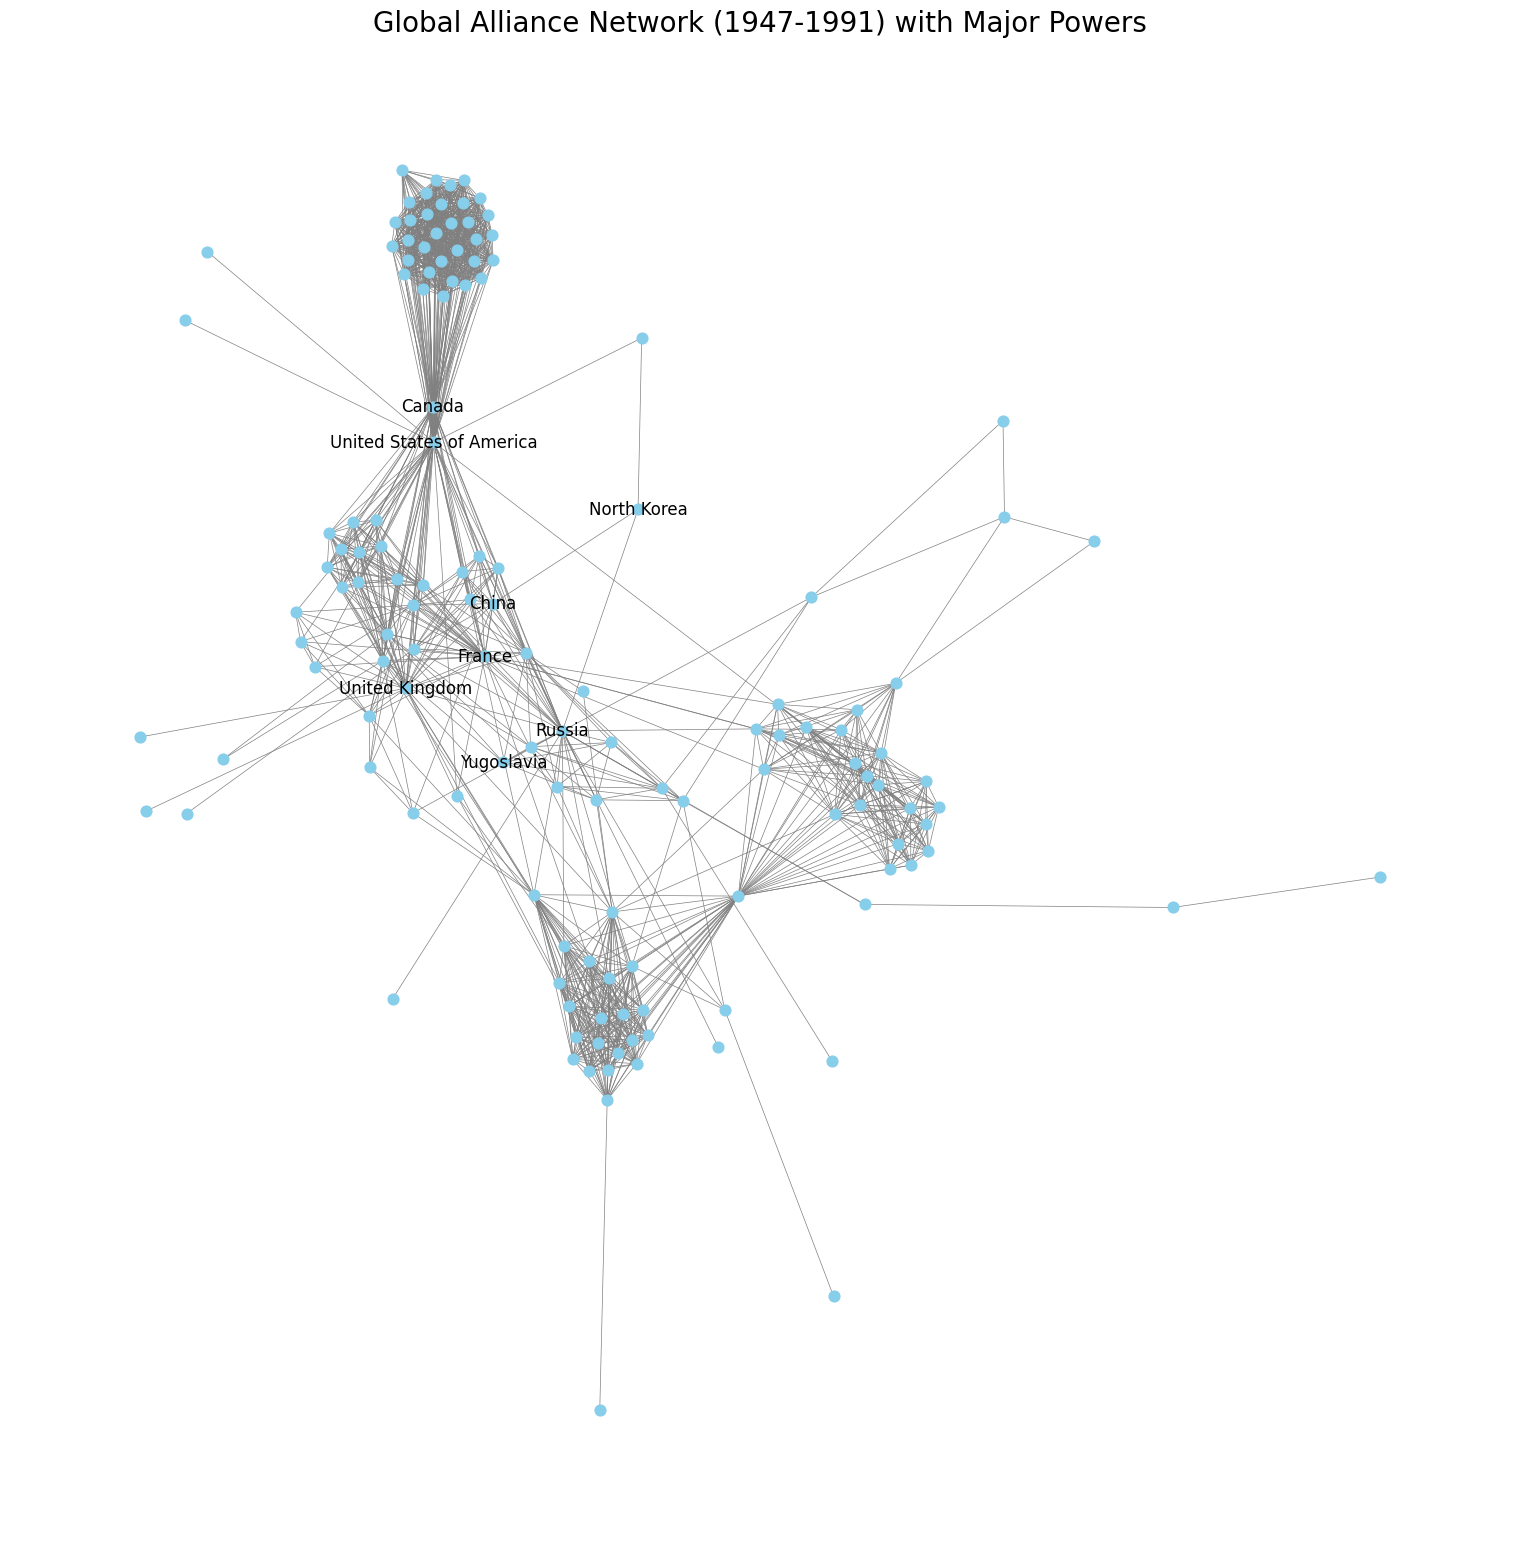

In [ ]:
# Create an empty graph
G = nx.Graph()

# Add edges from our DataFrame. We iterate through the rows to add each alliance.
for index, row in cold_war_df.iterrows():
    G.add_edge(row["ccode1"], row["ccode2"])

# Let's map the integer node labels to actual country names for clarity
G = nx.relabel_nodes(G, ccode_map)

# Print some basic network statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(
    f"\nThe network has {num_nodes} nodes (countries) and {num_edges} edges (alliances)."
)

# Now, let's try to visualize the network structure
plt.figure(figsize=(15, 15))
# The 'spring layout' algorithm positions nodes so that connected nodes are closer
pos = nx.spring_layout(G, iterations=50, seed=42)

# Draw the full network without any labels
nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=60,
    width=0.5,
    node_color="skyblue",
    edge_color="gray",
)

# Define the major powers you want to label
# Note: You may need to adjust these names to match exactly what's in your dataset.
# For COW data, 'Russia' is often used for the USSR.
major_powers = [
    "United States of America",
    "Russia",
    "United Kingdom",
    "France",
    "China",
    "Canada",
    "North Korea",
    "Yugoslavia",
]

# Create a dictionary of labels containing only the major powers
# This ensures we only attempt to label nodes that actually exist in our graph.
major_power_labels = {node: node for node in G.nodes() if node in major_powers}

# 4. Add the labels for the major powers to the plot
nx.draw_networkx_labels(
    G, pos, labels = major_power_labels, font_size=12, font_color="black"
)

plt.title("Global Alliance Network (1947-1991) with Major Powers", fontsize=20)
plt.show()

The graph reveals the bipolar structure of the Cold War. A dense cluster centered around the **United States**, **Canada**, and the **United Kingdom** represents the closely connected Western bloc. The eastern bloc emerges around **Russia** and is connected to allies such as **North Korea**.


## **Step 3: Analysis with Community Detection Algorithms**

Time to find the hidden geopolitical blocs quantitatively\!

### **Girvan-Newman Algorithm**

The Girvan-Newman algorithm is a classic "top-down" or **divisive** method for detecting communities. Instead of building communities from the ground up, it starts with the whole network and strategically splits it apart. Its main goal is to find the "fault lines" in a network by identifying and removing the edges that act as bridges between different communities.

#### The Core Idea: **Edge Betweenness**

The algorithm's power comes from a metric called edge betweenness centrality. This is a score given to every edge that measures how important it is for connecting different parts of the network.

- **Definition:** An edge's betweenness centrality is the number of shortest paths between all pairs of nodes in the network that run along that specific edge.
- **The Math:** The formula for the betweenness centrality $C_B(e)$ of an edge $e$ is:
  $$C_B(e) = \sum_{s \neq t} \frac{\sigma_{st}(e)}{\sigma_{st}}$$
  Where $\sigma_{st}$ is the total number of shortest paths between nodes $s$ and $t$, and $\sigma_{st}(e)$ is the number of those paths that pass through edge $e$.

Edges that connect dense clusters act as bridges, so they naturally lie on many shortest paths and get a high betweenness score.

- **Analogy:** Imagine you're a geographer trying to define continents. The Girvan-Newman method would be like identifying the narrowest land bridges (like Panama or Suez) that carry the most cross-continental traffic. By removing them one by one, the large, distinct landmasses (the communities) are revealed.

#### Why It's "Embarrassingly Sequential"

While powerful, the Girvan-Newman algorithm is computationally expensive and doesn't parallelize well. Here’s why:

1.  **Calculate:** The algorithm first calculates the betweenness for _every_ edge in the graph.
2.  **Remove:** It finds the single edge with the highest score and removes it.
3.  **Repeat from Scratch:** After removing just one edge, the shortest paths across the _entire graph_ can change dramatically. As a result, you have to **recalculate the betweenness for all remaining edges from scratch**.

This step-by-step dependency (calculate -> remove -> repeat) means the problem can't be broken down into independent chunks for a parallel framework like Dask to solve efficiently. Because our alliance network is relatively small, using the standard, well-optimized `networkx` implementation is the most practical approach.

### What is Modularity?

We choose the best community structure found during this process by maximizing a score called [**modularity**](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html), which measures how densely connected the nodes are within their assigned communities compared to a random network.

**Modularity** is a measure of the strength of a network's division into communities (or modules). It compares the number of edges _within_ a community to the number of edges you would _expect_ to find if the network were wired randomly while preserving the degree of each node.

- A **high modularity score** (approaching 1.0) indicates a good partition. It means there are many more edges within your identified communities and fewer edges between them than you'd expect by random chance. This suggests a strong, non-random community structure.
- A **modularity score near 0** implies the community structure is no better than random.
- A **negative score** means there are even fewer within-community links than expected by chance, indicating a poor partition.


In [ ]:
# The Girvan-Newman algorithm in networkx returns an iterator. Each step in the
# iteration corresponds to removing one more edge.
communities_generator = girvan_newman(G)

# We need to find the partition that gives the best modularity score.
best_modularity = -1.0
best_partition = None

# Iterate through the partitions, from coarse to fine
for partition in communities_generator:
    current_modularity = modularity(G, partition)
    if current_modularity > best_modularity:
        best_modularity = current_modularity
        best_partition = partition

print(
    f"Girvan-Newman found {len(best_partition)} communities with a modularity of {best_modularity:.3f}."
)

# Let's see who is in the largest communities
print("\n--- Top Communities (Girvan-Newman) ---")
# Sort communities by size to see the main players
sorted_communities = sorted(best_partition, key=len, reverse=True)

# Print first 10 members
for i, comm in enumerate(sorted_communities[:10]):
    print(f"Community {i} ({len(comm)} members): {list(comm)[:10]}...")

Girvan-Newman found 16 communities with a modularity of 0.601.

--- Top Communities (Girvan-Newman) ---
Community 0 (35 members): ['Brazil', 'United States of America', 'St. Vincent and the Grenadines', 'Paraguay', 'Trinidad and Tobago', 'Uruguay', 'St. Kitts and Nevis', 'Bahamas', 'Costa Rica', 'Bolivia']...
Community 1 (23 members): ['Liberia', 'Madagascar', 'Togo', 'Chad', 'Guinea', 'Senegal', 'Gambia', 'Benin', 'Cameroon', 'Guinea-Bissau']...
Community 2 (22 members): ['Yemen Arab Republic', 'Syria', 'Jordan', 'Qatar', 'Djibouti', 'Israel', 'Bahrain', 'Morocco', 'Saudi Arabia', 'Sudan']...
Community 3 (21 members): ['Cambodia', 'Bulgaria', 'Republic of Vietnam', 'Czechoslovakia', 'Romania', 'Hungary', 'Vietnam', 'Thailand', 'German Democratic Republic', 'Mongolia']...
Community 4 (20 members): ['Luxembourg', 'Greece', 'Australia', 'Philippines', 'Iceland', 'Norway', 'United Kingdom', 'Spain', 'Portugal', 'France']...
Community 5 (3 members): ['Zambia', 'Burundi', 'Democratic Republ

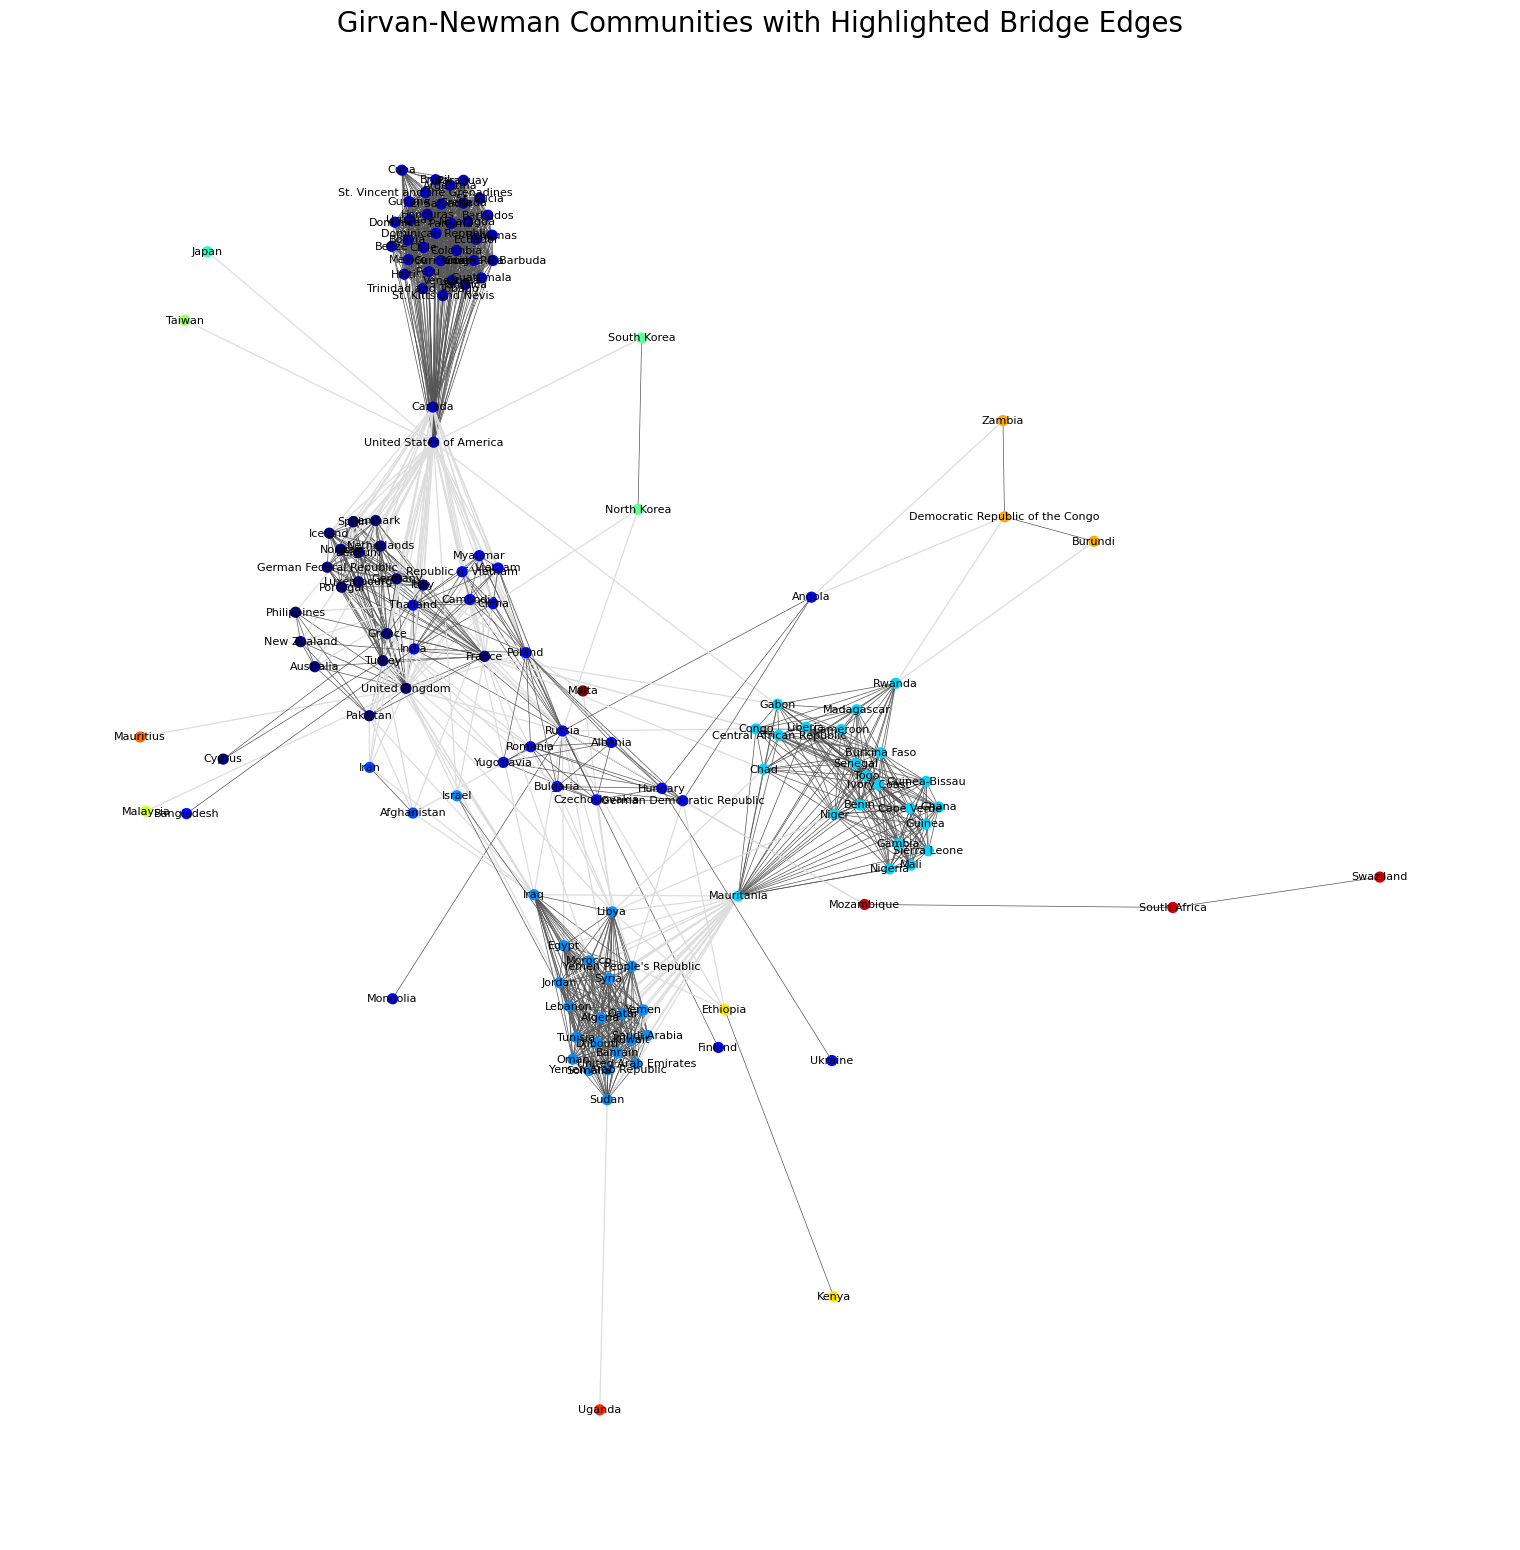

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Finally, let's visualize this partition
community_map = {}
for i, comm in enumerate(best_partition):
    for node in comm:
        community_map[node] = i

node_colors = [community_map[node] for node in G.nodes()]


# Create a list of colors and widths for the edges
edge_colors = []
edge_widths = []
for u, v in G.edges():
    # Check if the nodes of an edge belong to the same community
    if community_map[u] == community_map[v]:
        edge_colors.append("#555")  # Color for intra-community edges
        edge_widths.append(0.5)  # Thinner width for intra-community edges
    else:
        edge_colors.append("#ddd")  # Color for inter-community edges
        edge_widths.append(0.9)  # Thicker width for inter-community edges

plt.figure(figsize=(15, 15))
# Pass the edge color and width lists to the drawing function
nx.draw(
    G,
    pos,
    node_color=node_colors,
    with_labels=True,
    node_size=50,
    font_size=8,
    cmap=plt.cm.jet,
    edge_color=edge_colors,  # Apply the custom edge colors
    width=edge_widths,
)  # Apply the custom edge widths

plt.title("Girvan-Newman Communities with Highlighted Bridge Edges", fontsize=20)
plt.show()

The Girvan-Newman algorithm reveals a rich, multi-polar landscape of Cold War alliances -- moving beyond a simple East-West divide to reveal communities/blocs shaped by regional, historical, and political ties.

The Western alliance was split into two primary spheres of influence:
- **Community 0**, an Americas-focused bloc led by the **United States** reflecting the structure of the Organization of American States
- **Community 4**, centered on **European NATO** members and Commonwealth partners.

In contrast, **Community 3** forms a **diverse Eurasian bloc** encompassing the principal communist powers, **Russia** and **China**, alongside influential members of the **Non-Aligned Movement** such as **India** and **Yugoslavia** -- illustrating a coalition of nations operating largely outside the US-led system.

The algorithm also successfully identifies distinct **regional power centers**: a cohesive **Arab League bloc (Community 2)** spanning the Middle East and North Africa, and a **Sub-Saharan African group (Community 1)** likely bound by post-colonial affiliactions. Smaller, tightly knit groups, such as the two Koreas, represent localized geopolitical substructures within this broader global network.

### **Spectral Clustering**

This algorithm takes a different, "bottom-up" approach based on the graph's matrix representation. It is one of the most powerful and popular methods for community detection.

- **Analogy:** Think of the network as a physical object, like a drum skin. Spectral clustering analyzes how this object "vibrates." Groups of nodes that move together in the primary modes of vibration form natural communities. It's excellent at finding clean, well-defined clusters, even with complex shapes that other algorithms might miss.

Unlike Girvan-Newman, you must specify the number of communities (`k`) you expect to find. Based on our historical knowledge and the Girvan-Newman result for this task, looking for two or three major blocs is a reasonable start.

#### **The Laplacian Matrix**

The algorithm transforms the graph structure into a special matrix called the **Graph Laplacian ($L$)**, which captures essential information about how nodes are connected. It is defined as:

$$L = D - A$$


- **$A$** is the **Adjacency Matrix**. This is a simple matrix where $A_{ij} = 1$ if there is an edge between node $i$ and node $j$, and $0$ otherwise. It tells us exactly which nodes are connected.
- **$D$** is the **Degree Matrix**. This is a diagonal matrix where the entry $D_{ii}$ is the degree of node $i$ (i.e., the number of connections it has). All other entries are zero.

The Laplacian matrix beautifully encodes the graph's structure, and its properties are central to the clustering process.

#### **Partitioning with Eigenvalues and Eigenvectors**

In spectral clustering, eigenvalues of the graph's Laplacian matrix are helpful because they measure the "cost" of cutting the network into different communities. A small eigenvalue indicates that the graph has a natural "bottleneck" or a sparse connection between two dense groups of nodes, making it an ideal place to partition the network.

While the eigenvalue tells us how good a potential cut is, the corresponding eigenvector tells us where to make that cut.

For the smallest non-zero eigenvalue (known as the **Fiedler value**), its associated eigenvector (the **Fiedler vector**) assigns a single number to each node in the graph. Nodes within the same natural community will have very similar values, while nodes across the "bottleneck" will have very different values (e.g., some positive, some negative).

By simply looking at the signs of the values in this vector, you can make a powerful first cut to divide the network into two communities. To find _k_ communities, spectral clustering simply uses the first _k_ eigenvectors, which represent the _k_ "easiest" ways to partition the network.


In [ ]:
# Get Edge List & Apply Mapping
# Bring the edge list into memory and convert country codes to matrix indices.
edges = cold_war_ddf[["ccode1", "ccode2"]].compute()
row_indices = edges["ccode1"].map(node_map).values
col_indices = edges["ccode2"].map(node_map).values


# Build the SciPy Sparse Adjacency Matrix
data = np.ones(len(row_indices))
adj_matrix_sparse = coo_matrix(
    (data, (row_indices, col_indices)), shape=(n_nodes, n_nodes)
)
# Ensure the matrix is symmetric for the undirected alliance graph
adj_matrix_sparse = adj_matrix_sparse + adj_matrix_sparse.T

In [ ]:
# Perform Scikit-learn Clustering
# We use 'precomputed' because we are providing the final affinity matrix.
sc = SpectralClustering(
    n_clusters=2, affinity="precomputed", assign_labels="kmeans", random_state=42
)

labels = sc.fit_predict(adj_matrix_sparse)

# You can now use the 'labels' array for analysis and visualization.
print(
    f"Successfully clustered {n_nodes} countries into {len(np.unique(labels))} communities."
)

Successfully clustered 139 countries into 2 communities.



--- Top Communities (Scikit-learn Spectral Clustering, k=2) ---
Community 0 (51 members): [645, 435, 520, 522, 600, 615, 616, 620, 625, 678]...
Community 1 (88 members): [200, 130, 365, 315, 630, 145, 100, 900, 2, 40]...


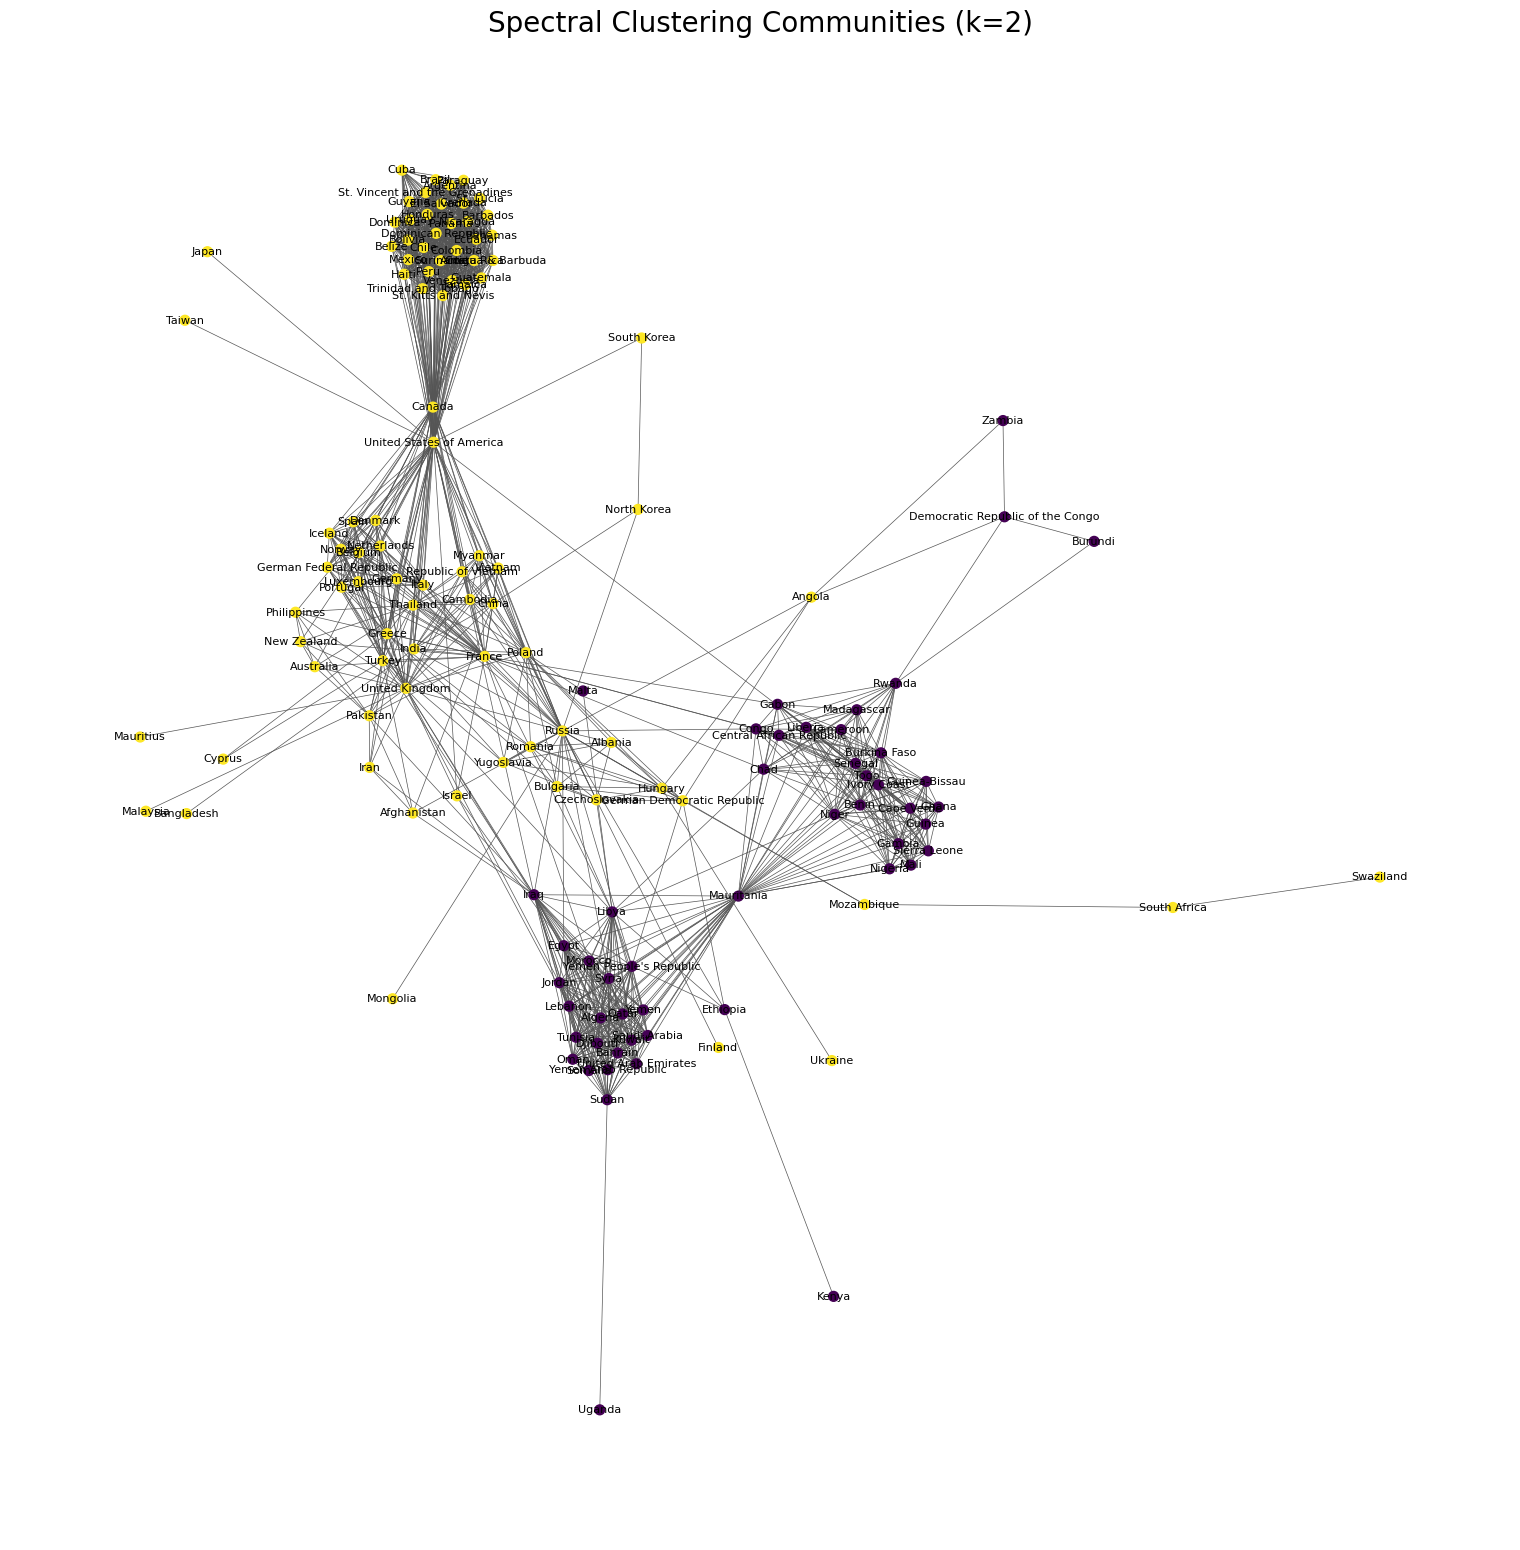

In [ ]:
# First, let's see which countries are in each cluster.
# We need a list that maps the matrix index back to the country code.
node_list = node_map.index.to_list()

print("\n--- Top Communities (Scikit-learn Spectral Clustering, k=2) ---")
community_0 = [node_list[i] for i, label in enumerate(labels) if label == 0]
community_1 = [node_list[i] for i, label in enumerate(labels) if label == 1]
print(f"Community 0 ({len(community_0)} members): {community_0[:10]}...")
print(f"Community 1 ({len(community_1)} members): {community_1[:10]}...")


# Now, let's create the plot.
plt.figure(figsize=(15, 15))

# Create a mapping from the country code in G to its cluster label for coloring
label_map = {node: labels[name_to_index[node]] for node in G.nodes()}
node_colors = [label_map[node] for node in G.nodes()]

# Create a list of colors and widths for the edges
edge_colors = []
edge_widths = []
for u, v in G.edges():
    edge_colors.append("#555")  # Color for intra-community edges
    edge_widths.append(0.5)  # Thinner width for intra-community edges

# Draw the network, coloring nodes by their community
nx.draw(
    G,
    pos,
    node_color=node_colors,
    with_labels=True,
    node_size=50,
    font_size=8,
    edge_color=edge_colors,
    width=edge_widths,
    cmap=plt.cm.viridis,
)

plt.title("Spectral Clustering Communities (k=2)", fontsize=20)
plt.show()

This network graph visualizes a spectral clustering of nations into two communities (yellow and purple) based on Cold War-era alliances.

The large **yellow cluster** represents a highly interconnected "core" of global powers. It includes not only the United States and its Western Bloc allies but also, counterintuitively, the Soviet Union/Russia and several of its allies. This suggests that the algorithm detected a dense web of interconnections linking both superpowers and their major spheres of influence, grouping them into a single, globally integrated core.

In contrast, the **purple cluster** primarily comprises **African and Asian nations**, including **China** and **North Korea**. This community can be interpreted as a more "peripheral" community, consisting largely of states from the Non-Aligned Movement or those maintaining looser connections to the central U.S. - Soviet rivalry.

Overall, the clustering reveals a **core–periphery structure** within the Cold War network—offering a more nuanced perspective than a simple capitalist-versus-communist division.

## Using Modularity to Find the Optimal 'k'

While spectral clustering requires you to pre-define `k`, it doesn't offer a built-in way to know which `k` is "correct." Modularity provides a principled way to answer this question by giving us a score for how well-defined a community structure is.

We'll run spectral clustering for a range of `k` values, calculate the modularity score for each resulting partition, and then identify the `k` that yields the highest score.


In [ ]:
import networkx as nx
from networkx.algorithms.community import modularity
from sklearn.cluster import SpectralClustering
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a range of k values to test
k_range = range(2, 11)  # Test for 2 through 10 communities
modularity_scores = []

# We need the original node list to map cluster labels back to node IDs
node_list = node_map.index.to_list()

# 2. Loop through each k, perform clustering, and calculate modularity
print("Calculating modularity for different values of k...")
for k in k_range:
    # Perform spectral clustering for the current k
    sc = SpectralClustering(
        n_clusters=k, affinity="precomputed", assign_labels="kmeans", random_state=42
    )
    labels = sc.fit_predict(adj_matrix_sparse)

    # The modularity function in NetworkX requires communities as sets of nodes.
    # We need to convert the labels array from scikit-learn into this format.
    communities = [set() for _ in range(k)]
    for i, label in enumerate(labels):
        # Map the matrix index 'i' back to the original country code/name
        communities[label].add(index_to_name[i])

    # Remove any empty communities that might arise
    communities = [c for c in communities if c]

    # Calculate modularity for this partition
    score = modularity(G, communities)
    modularity_scores.append(score)
    print(f"k = {k}, Modularity = {score:.4f}")

# 3. Find the best k
best_k = k_range[np.argmax(modularity_scores)]
max_modularity = max(modularity_scores)
print(f"\nOptimal k = {best_k} with a modularity score of {max_modularity:.4f}")

Calculating modularity for different values of k...
k = 2, Modularity = 0.4205
k = 3, Modularity = 0.4590
k = 4, Modularity = 0.6119
k = 5, Modularity = 0.4505
k = 6, Modularity = 0.4735
k = 7, Modularity = 0.4765
k = 8, Modularity = 0.4351
k = 9, Modularity = 0.3882
k = 10, Modularity = 0.4285

Optimal k = 4 with a modularity score of 0.6119


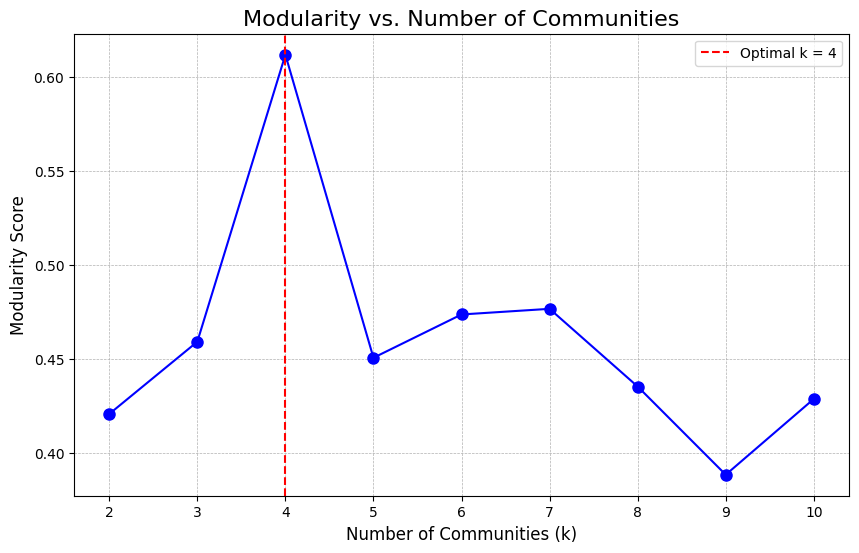

In [ ]:
# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, modularity_scores, "bo-", markersize=8)
plt.xlabel("Number of Communities (k)", fontsize=12)
plt.ylabel("Modularity Score", fontsize=12)
plt.title("Modularity vs. Number of Communities", fontsize=16)
plt.axvline(best_k, color="r", linestyle="--", label=f"Optimal k = {best_k}")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

### Visualizing the Optimal Partition (k=4)

Now we've determined that `k=4` yields the highest modularity score, the final step is to visualize this specific partition. This allows us to inspect the four communities and see if they correspond to a meaningful geopolitical structure during the Cold War.

The code below first runs the spectral clustering algorithm one last time with the optimal `k=4`. Then, it maps the resulting community labels to the nodes in the graph to color them accordingly.


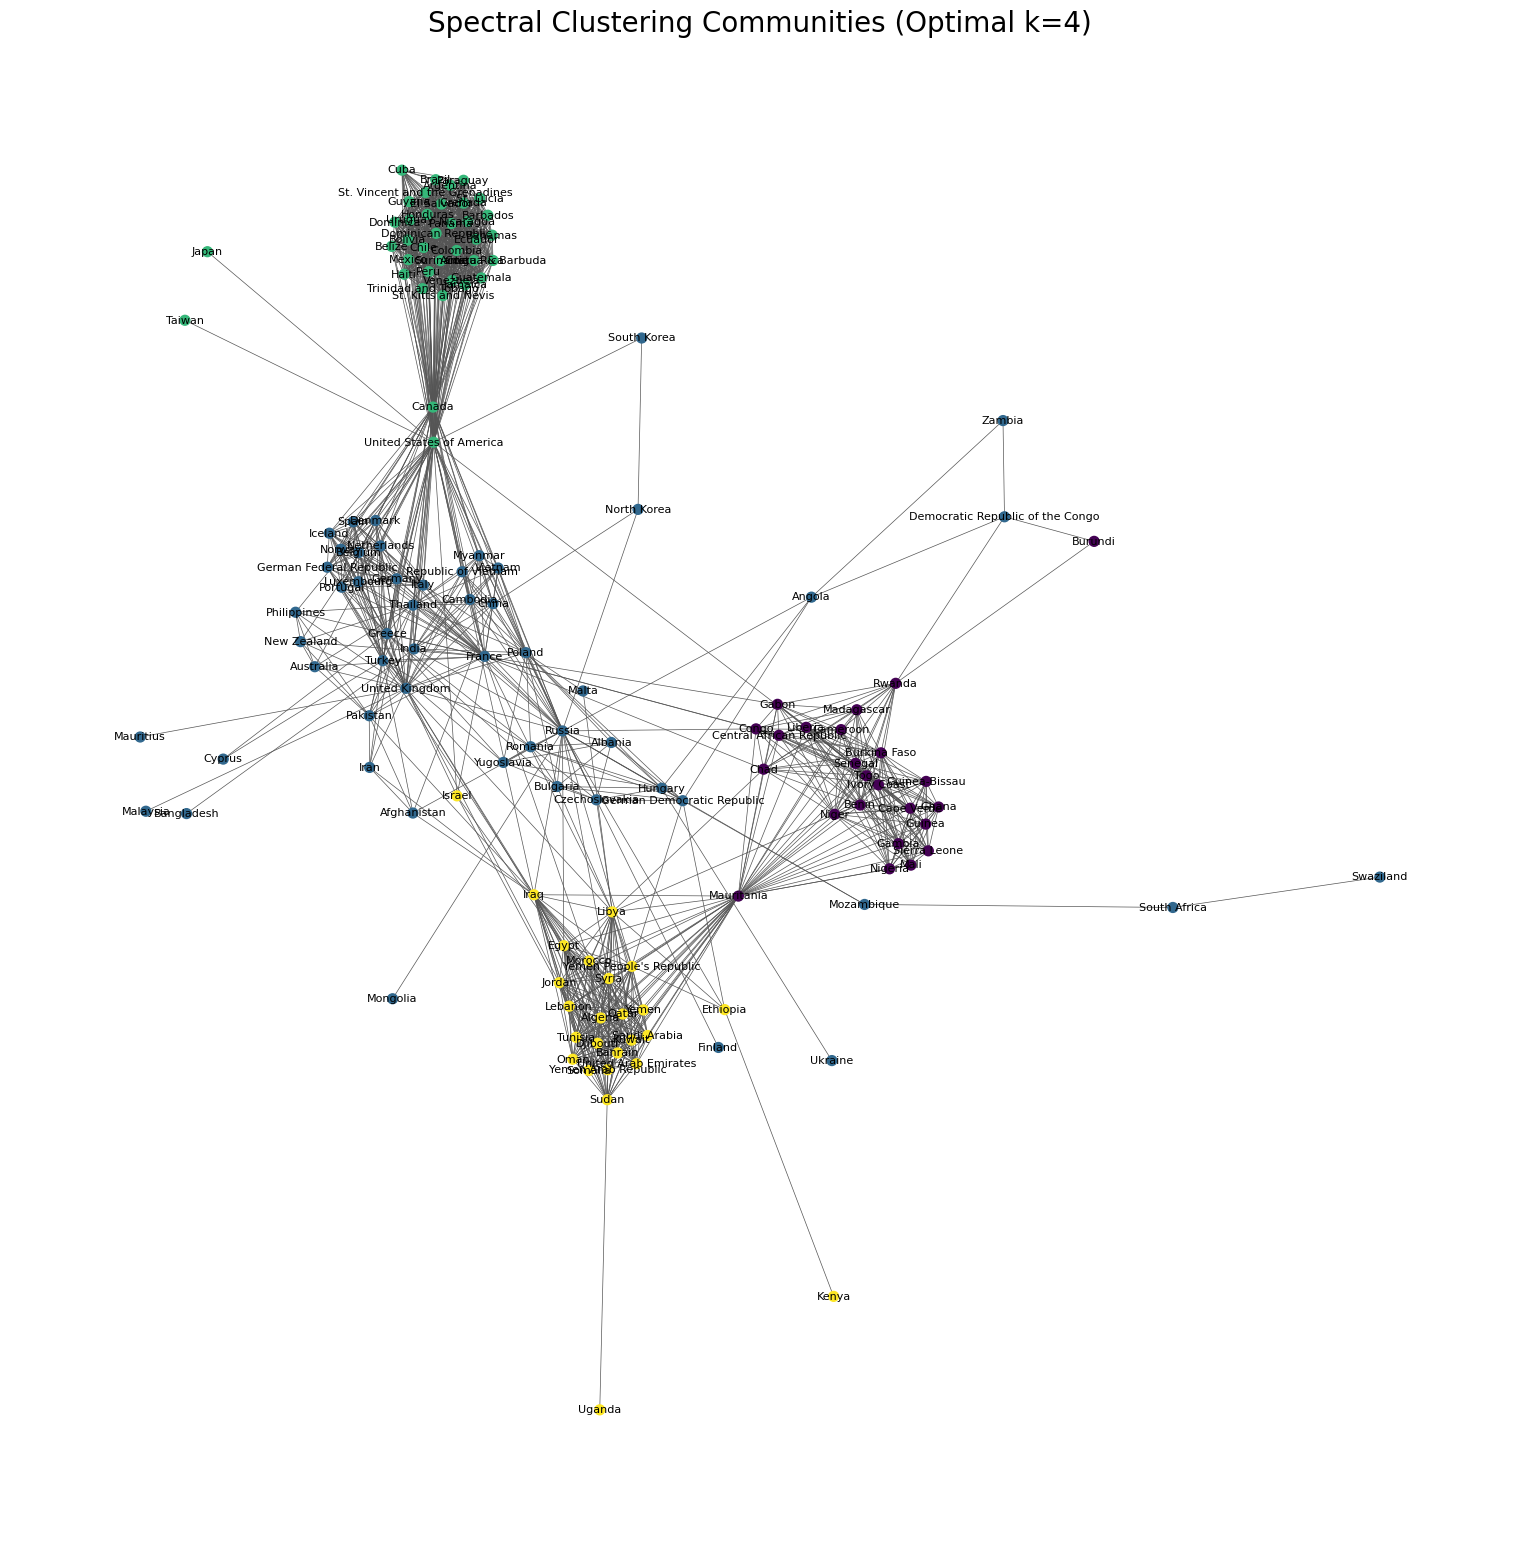

--- Communities for Optimal k=4 ---

Community 0 (24 members):
['Mauritania', 'Chad', 'Mali', 'Niger', 'Ivory Coast', 'Cameroon', 'Gabon', 'Congo', 'Cape Verde', 'Liberia', 'Sierra Leone', 'Central African Republic', 'Guinea', 'Senegal', 'Benin']

Community 1 (53 members):
['United Kingdom', 'Russia', 'Czechoslovakia', 'Iran', 'Australia', 'Hungary', 'Bulgaria', 'Luxembourg', 'German Federal Republic', 'Greece', 'Norway', 'Denmark', 'Iceland', 'Pakistan', 'Thailand']

Community 2 (37 members):
['Ecuador', 'Bolivia', 'Colombia', 'United States of America', 'Cuba', 'Dominican Republic', 'Honduras', 'Nicaragua', 'Venezuela', 'Peru', 'Brazil', 'Canada', 'Trinidad and Tobago', 'Barbados', 'Dominica']

Community 3 (25 members):
['Iraq', 'Somalia', 'Djibouti', 'Morocco', 'Algeria', 'Tunisia', 'Libya', 'Sudan', 'Yemen Arab Republic', 'Yemen', "Yemen People's Republic", 'United Arab Emirates', 'Kenya', 'Israel', 'Saudi Arabia']


In [ ]:
# 1. Rerun spectral clustering for the optimal k=4
best_k = 4
sc_best = SpectralClustering(
    n_clusters=best_k, affinity="precomputed", assign_labels="kmeans", random_state=42
)
labels_best = sc_best.fit_predict(adj_matrix_sparse)

# 2. Create a mapping from node ID to its community label for coloring
community_map_best = {index_to_name[i]: labels_best[i] for i in range(len(node_list))}
node_colors_best = [community_map_best.get(node) for node in G.nodes()]

# 3. Create the plot
plt.figure(figsize=(15, 15))

nx.draw(
    G,
    pos,
    node_color=node_colors_best,
    with_labels=True,
    node_size=50,
    font_size=8,
    edge_color="#555",
    width=0.5,
    cmap=plt.cm.viridis,
)  # A distinct colormap for the communities

plt.title(f"Spectral Clustering Communities (Optimal k={best_k})", fontsize=20)
plt.show()

# 4. (Optional) Print the members of each community to inspect them
print(f"--- Communities for Optimal k={best_k} ---")
communities_best = [[] for _ in range(best_k)]
for node, label in community_map_best.items():
    # We use ccode_map to get the full country name
    communities_best[label].append(ccode_map.get(node, str(node)))

for i, comm in enumerate(communities_best):
    print(f"\nCommunity {i} ({len(comm)} members):")
    print(comm[:15])  # Print the first 15 members

### Interpretation

This spectral clustering graph with `k=4` provide an even clearer delineation of nations, effectively grouping them into distinct spheres of influence.

#### 🟢 Green: The US-Led Western Bloc

This cluster represents the core US sphere of influence. Dominated by the **United States, Canada, and nations of South and Central America**, its coherence is defined by formal military alliances like **NATO** and the **Rio Treaty**, as well as deep economic and political ties. These countries formed the principal anti-Soviet coalition, bound together by capitalist economies and a shared opposition to the spread of communism. This was the heart of the Western alliance.

#### 🔵 Blue: The Core Soviet & Communist Bloc

This cluster represent the core of the Soviet sphere of influence. It includes the **Warsaw Pact** nations of Eastern Europe (like Poland and Hungary), alongside other major communist states such as **China** and **North Korea**. These nations were bound by communist ideology and, for the most part, were politically, economically, and militarily subordinate to the USSR. The interesting inclusion of the **UK** is likely an anomaly of the clustering algorithm, possibly due to its extensive and unique global network of diplomatic ties.

#### 🟡 Yellow: The "Revolutionary" Soviet-Leaning Bloc

The yellow cluster identifies key **Soviet client states** in the "Third World," primarily in the Middle East and Africa. Nations like **Iraq, Libya, Syria, and Ethiopia** were not formal members of the Warsaw Pact but adopted revolutionary, socialist, or anti-Western ideologies. They became crucial Soviet allies, receiving significant military and economic aid in exchange for opposing US interests and providing strategic footholds in their regions. They represent a distinct sphere of strong Soviet influence outside the core communist bloc.

#### 🟣 Purple: The Non-Aligned & Contested Bloc

This cluster is predominantly composed of **post-colonial African nations** that were central to the **Non-Aligned Movement** or were active battlegrounds for superpower competition. Countries like **Nigeria, Rwanda, Mozambique, and Burkina Faso** define this group. Their shared feature was a more fluid geopolitical stance; they often resisted firm allegiance to either superpower, hosted proxy conflicts, or had shifting alignments over time. This cluster doesn't represent a unified alliance but rather a shared experience of navigating the pressures of the Cold War from a position of strategic independence or vulnerability.

Compare the countries in these clusters to the ones found by Girvan-Newman. Do you think this is a better clustering?

## **What's Next? 🤔**

This analysis serves as just a starting point. Here are a few directions for further exploration:

- **Track Blocs Over Time:** Wrap the analysis code in a loop to generate a network for each decade. How did the global community structure change from the 1950s to the 1980s? When did the bipolar world truly emerge and dissolve?
- **Explore Other Algorithms:** The [Louvain method](https://python-louvain.readthedocs.io/en/latest/) is an extremely fast and popular algorithm for community detection. Does it produce better results?
- **Find Overlapping Communities:** Countries often belong to multiple communities (e.g., a military alliance and a trade bloc). Explore algorithms like the **Affiliation-Graph Model (AGM)** that allow nodes to have multiple memberships.
